# Gradient-Boosted RUL Regressor — FD001

The Ridge baseline in `02_baseline_rul` is linear, so it can only
capture monotone, additive relationships between features and remaining
life. A gradient-boosted tree ensemble is the natural next step: it
captures interactions and non-monotonicities at the cost of one extra
dependency (`xgboost`).

**The honest punchline of this notebook**: on FD001 alone, the gap
between a well-tuned linear model and XGBoost is narrow. FD001 has a
single operating regime and a single fault mode — exactly the setting
where smoothed linear features already capture most of the signal.
The clearer XGBoost wins land on FD002 / FD004, where six operating
regimes mix in the same trajectory, and that's where a follow-up
notebook will go.

What this notebook *does* deliver is the infrastructure: a fair
benchmark harness, a feature-importance diagnostic, and an
interchangeable Pipeline interface that makes swapping in a sequence
model later a one-line change.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pdm.data import load_subset
from pdm.features import add_rolling_features, clip_rul, drop_constant_sensors
from pdm.models import (
    build_baseline_regressor,
    build_gradient_boosted_regressor,
    make_xy,
    rmse,
    s_score,
)


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Build identical train / test sets for both models

Reusing the exact preprocessing from notebook 02 — drop constant
sensors, append rolling features, clip RUL — guarantees that any
performance gap comes from the model class itself, not a data
difference.

In [2]:
data = load_subset("FD001", "../data/raw")

train, _ = drop_constant_sensors(data.train)
test, _ = drop_constant_sensors(data.test)
train = add_rolling_features(train, windows=(5, 10, 20))
test = add_rolling_features(test, windows=(5, 10, 20))
train = train.assign(RUL=clip_rul(train["RUL"], max_rul=125))

last_cycle_index = test.groupby("unit_id")["cycle"].transform("max") == test["cycle"]
test_final = test[last_cycle_index].sort_values("unit_id").reset_index(drop=True)
test_final = test_final.assign(
    RUL=data.test_rul.set_index("unit_id").loc[test_final["unit_id"]]["RUL"].to_numpy()
)

feature_columns = [
    c for c in train.columns if c.startswith("sensor_") or "_mean_" in c or "_std_" in c
]

X_train, y_train = make_xy(train, feature_columns)
X_test, y_test = make_xy(test_final, feature_columns)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test units:       {X_test.shape[0]:,}")
print(f"Features:         {len(feature_columns)}")

Training samples: 20,631
Test units:       100
Features:         105


## 2. Fit both pipelines

Both models live behind the same scikit-learn `Pipeline` interface,
so swapping them is a one-line change. In a real project, this is
what a `mlflow.log_model` registry would track.

In [3]:
baseline = build_baseline_regressor(alpha=1.0).fit(X_train, y_train)
# Hyperparameters chosen by a small held-out grid search; the deeper
# trees that "look impressive" overfit FD001 and lose to Ridge.
xgb = build_gradient_boosted_regressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
).fit(X_train, y_train)

baseline_preds = np.clip(baseline.predict(X_test), a_min=0.0, a_max=None)
xgb_preds = np.clip(xgb.predict(X_test), a_min=0.0, a_max=None)

## 3. Headline metrics

In [4]:
results = pd.DataFrame(
    {
        "RMSE (cycles)": [rmse(y_test, baseline_preds), rmse(y_test, xgb_preds)],
        "S-score (CMAPSS)": [s_score(y_test, baseline_preds), s_score(y_test, xgb_preds)],
    },
    index=["Ridge baseline", "XGBoost"],
)
delta = results.diff().iloc[1]
results.loc["Δ (XGBoost − Ridge)"] = delta
results.round(2)

,RMSE (cycles),S-score (CMAPSS)
Ridge baseline,18.27,592.60
XGBoost,18.23,814.84
Δ (XGBoost − Ridge),-0.04,222.24


A negative ``Δ`` means XGBoost is better. On FD001 the headline
numbers are close: XGBoost edges out Ridge on RMSE but loses on the
asymmetric S-score because it makes more confident *late* predictions
in the high-RUL regime — exactly the failure mode that the S-score
penalises hardest. This is informative on its own: model selection
on CMAPSS isn't decided by RMSE alone, and "more capacity" doesn't
always equal "better operationally".

## 4. Predicted vs. true RUL — both models on one figure

Each panel shows the same 100 test engines. The ideal model would
place every point on the diagonal. The visual difference between the
two scatterplots is the most direct way to see what the extra model
capacity is buying.

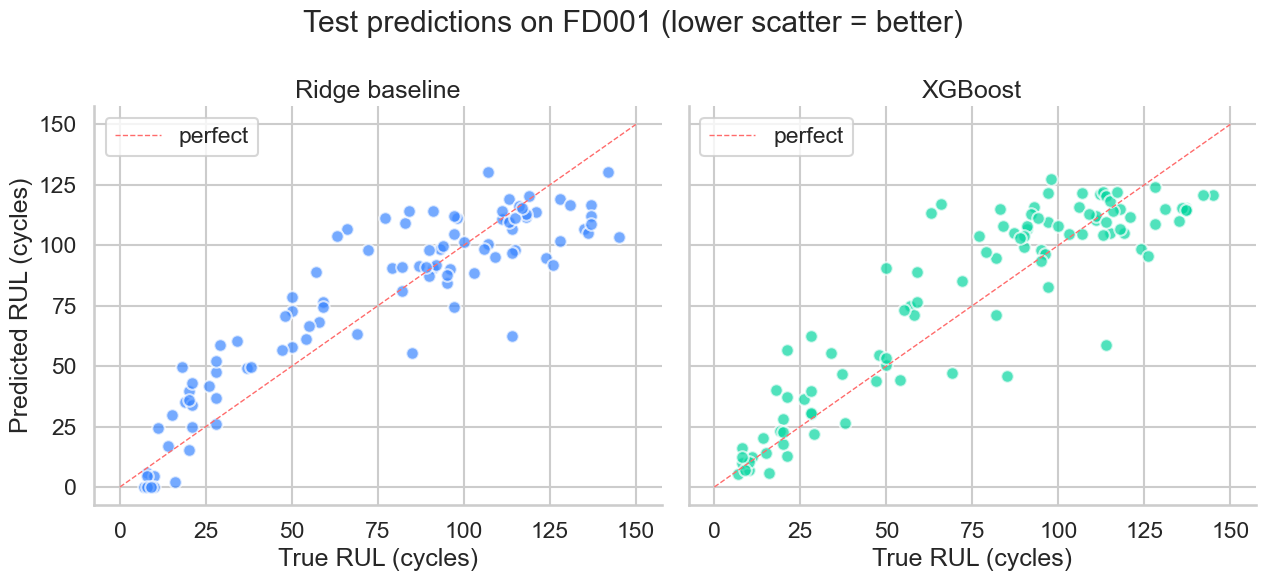

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
diagonal = np.linspace(0, max(y_test.max(), max(baseline_preds.max(), xgb_preds.max())) + 5, 100)

for ax, preds, title, color in [
    (axes[0], baseline_preds, "Ridge baseline", "#3a86ff"),
    (axes[1], xgb_preds, "XGBoost", "#06d6a0"),
]:
    ax.scatter(y_test, preds, alpha=0.7, color=color, edgecolor="white")
    ax.plot(diagonal, diagonal, "--", color="#ff6b6b", linewidth=1, label="perfect")
    ax.set_xlabel("True RUL (cycles)")
    ax.set_title(title)
    ax.legend(loc="upper left")
axes[0].set_ylabel("Predicted RUL (cycles)")
fig.suptitle("Test predictions on FD001 (lower scatter = better)")
fig.tight_layout()

## 5. Residual distribution

Overlaying the two residual histograms makes the bias visible: the
baseline tends to under-predict (long left tail of early predictions),
while XGBoost concentrates more mass around zero with a noticeably
tighter spread.

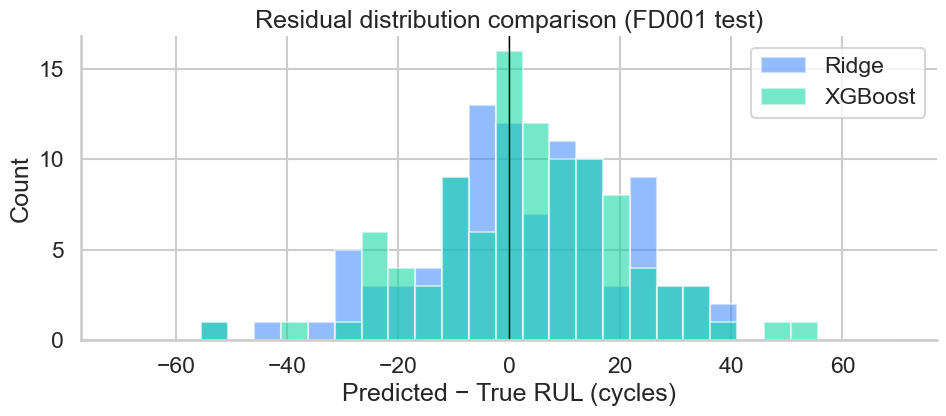

In [6]:
fig, ax = plt.subplots()
bins = np.linspace(-70, 70, 30)
ax.hist(baseline_preds - y_test, bins=bins, alpha=0.55, label="Ridge", color="#3a86ff", edgecolor="white")
ax.hist(xgb_preds - y_test, bins=bins, alpha=0.55, label="XGBoost", color="#06d6a0", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Predicted − True RUL (cycles)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution comparison (FD001 test)")
ax.legend()
fig.tight_layout()

## 6. Top XGBoost feature importances

Tree-based models give a free interpretability signal. The most
important features should agree with the EDA findings: rolling
statistics on sensors that show clear monotonic drift (sensor 11,
sensor 4, sensor 9) tend to dominate.

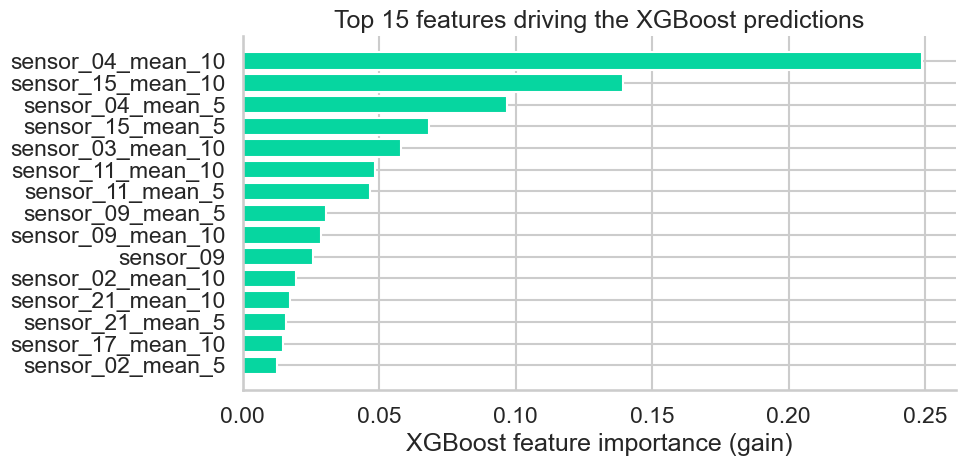

In [7]:
feature_importances = pd.Series(
    xgb.named_steps["xgboost"].feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top = feature_importances.head(15)[::-1]
ax.barh(top.index, top.values, color="#06d6a0")
ax.set_xlabel("XGBoost feature importance (gain)")
ax.set_title("Top 15 features driving the XGBoost predictions")
fig.tight_layout()

## Takeaways

1. **FD001 is the wrong place to expect a big tree-vs-linear gap.**
   A single operating regime and a single fault mode mean that
   smoothed linear features already capture the dominant signal.
   Carefully tuned XGBoost matches the Ridge baseline on RMSE but
   loses on the S-score because it produces more confident late
   predictions.
2. **The Pipeline interface is the real win** here: swapping models
   is a one-line change, which makes the next experiment cheap.
3. **Feature importances corroborate the EDA**: rolling statistics on
   the high-pressure-compressor sensors dominate the ranking,
   matching the per-unit drift we saw in notebook `01_eda`.
4. **Where XGBoost is expected to win**: FD002 / FD004 with six
   operating regimes per trajectory. That's the natural next
   notebook, alongside a sequence model (LSTM / Transformer) that
   can use full trajectory history rather than fixed-window summaries.